In [1]:
from  clean_code.flexible_bitter_llm import (
    FlexibleBitterLLM, 
    LinearGater, 
    text_to_tensor, 
    per_token_losses_backbone
)

from training_random_base_model.hparam_utils import get_model_kwargs
from training_random_base_model.run import add_linear_model_kwargs
from flexify_training.run import add_flexi_model_kwargs
from data_processing import split_fineweb

from transformers import AutoTokenizer

from accelerate import Accelerator


from tqdm import tqdm

import torch
from torch.utils.data import DataLoader
device = torch.device("cuda")

In [2]:
byte_tokenizer = AutoTokenizer.from_pretrained("evabyte/EvaByte", trust_remote_code=True)

flexi_checkpoint_path = "flexify_training/checkpoints/32M_2025.09.01_09.56"

flexi_kwargs = get_model_kwargs("32M")
add_flexi_model_kwargs(flexi_kwargs)
add_linear_model_kwargs(flexi_kwargs)
flexi_kwargs["vocab_size"] = len(byte_tokenizer)

standard_checkpoint_path = "training_random_base_model/checkpoints/32M_2025.08.31_12.06"

standard_kwargs = get_model_kwargs("32M")
add_linear_model_kwargs(standard_kwargs)
standard_kwargs["vocab_size"] = len(byte_tokenizer)

flexi_kwargs


{'vocab_size': 320,
 'downsample_rate': 0.25,
 'sliding_window': 64,
 'GaterClass': clean_code.modules.LinearGater,
 'DownSamplerClass': clean_code.flexible_bitter_llm.SelectTokenDownsampler,
 'embedding_dim': 512,
 'num_heads': 8,
 'n_down_layers': 2,
 'n_mid_layers': 6,
 'n_up_layers': 2,
 'DownsampleRateEmbeddingClass': clean_code.flexible_bitter_llm.DownsampleRateEmbedding}

In [3]:
standard_kwargs

{'vocab_size': 320,
 'downsample_rate': 0.25,
 'sliding_window': 64,
 'GaterClass': clean_code.modules.LinearGater,
 'DownSamplerClass': clean_code.flexible_bitter_llm.SelectTokenDownsampler,
 'embedding_dim': 512,
 'num_heads': 8,
 'n_down_layers': 2,
 'n_mid_layers': 6,
 'n_up_layers': 2}

In [4]:
accelerator = Accelerator()

flexi_model = FlexibleBitterLLM(**flexi_kwargs).to(device, dtype=torch.bfloat16)
flexi_model = accelerator.prepare(flexi_model)
accelerator.load_state(flexi_checkpoint_path)

accelerator = Accelerator()

standard_model = FlexibleBitterLLM(**standard_kwargs).to(device, dtype=torch.bfloat16)
standard_model = accelerator.prepare(standard_model)
accelerator.load_state(standard_checkpoint_path)


using self._attn_implementation='flash_attention_2'


using self._attn_implementation='flash_attention_2'


In [5]:
_, _, test_set = split_fineweb.get_splits()
test_dataloader = DataLoader(
    test_set,
    batch_size=8
)

Loading dataset from disk:   0%|          | 0/549 [00:00<?, ?it/s]

In [ ]:
downsample_rates = list(0.95**i for i in range(45))
downsample_rates


[1.0,
 0.95,
 0.9025,
 0.8573749999999999,
 0.8145062499999999,
 0.7737809374999998,
 0.7350918906249998,
 0.6983372960937497,
 0.6634204312890623,
 0.6302494097246091,
 0.5987369392383787,
 0.5688000922764597,
 0.5403600876626367,
 0.5133420832795048,
 0.48767497911552954,
 0.46329123015975304,
 0.44012666865176536,
 0.4181203352191771,
 0.3972143184582182,
 0.37735360253530725,
 0.3584859224085419,
 0.3405616262881148,
 0.323533544973709,
 0.3073568677250236,
 0.2919890243387724,
 0.27738957312183377,
 0.26352009446574204,
 0.2503440897424549,
 0.23782688525533216,
 0.22593554099256555,
 0.21463876394293727,
 0.2039068257457904,
 0.19371148445850087,
 0.18402591023557582,
 0.174824614723797,
 0.16608338398760716,
 0.1577792147882268,
 0.14989025404881545,
 0.14239574134637467,
 0.13527595427905592,
 0.12851215656510312,
 0.12208654873684796,
 0.11598222130000556,
 0.11018311023500528,
 0.10467395472325501]

In [7]:
batch = next(iter(test_dataloader))
batch, _ = text_to_tensor(batch, byte_tokenizer, 4096, device)

@torch.no_grad()
def standard_model_forced_downsample_rate(batch, downsample_rate):
    """
    Forces the downsample rate of the standard model by prescribing the gate samples
    corresponding to the top-k down gate logits to be 1.0.
    """
    _, seq_length = batch.shape
    k = int(seq_length * downsample_rate)

    # Forward pass 1: get the top k down gate logits.
    out_standard_model = standard_model(batch)
    out_standard_model.keys()

    topk_result = out_standard_model["down_gate_logits"].topk(k, dim=-1)
    topk_indices = topk_result.indices

    # Create a tensor of zeros with the same shape as the gate logits.
    gate_samples = torch.zeros_like(out_standard_model["down_gate_logits"])

    # Use scatter to assign value of 1.0 to the top-k indices.
    gate_samples.scatter_(-1, topk_indices, 1.0)

    # Forward pass 2: do the forward pass with these gate samples.
    return standard_model(batch, prescribed_down_gate_samples=gate_samples)


standard_model_forced_downsample_rate(batch, 0.25)["down_gate_samples"].sum(dim=-1)

tensor([1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024], device='cuda:0')

In [8]:
total_batches = 10
max_seq_length = 4096

with torch.no_grad():
    import pandas as pd
    
    results = []
    
    for model_name, model in [("flexi", flexi_model), ("standard", standard_model_forced_downsample_rate)]:
        for downsample_rate_target in tqdm(downsample_rates, desc="downsample rates"):
            for i, batch in enumerate(test_dataloader):
                
                batch, loss_mask = text_to_tensor(
                    batch, 
                    byte_tokenizer, 
                    max_seq_length, 
                    device
                )

                out_model = model(batch, downsample_rate=downsample_rate_target)
                gates = out_model["down_gate_samples"]
                true_downsample_rate = gates.to(torch.float32).mean()

                per_token_losses = per_token_losses_backbone(
                    batch, 
                    loss_mask, 
                    out_model, 
                    out_model["down_gate_probs"], 
                    learn_gating=True,
                    early_exit_advantage_estimate=True
                )

                mean_next_token_cross_entropy = per_token_losses["next_token_cross_entropy"].mean()
                mean_early_next_token_cross_entropy = per_token_losses["early_next_token_cross_entropy"].mean()
                
                results.append({
                    'model_name': model_name,
                    'downsample_rate': downsample_rate_target,
                    'true_downsample_rate': true_downsample_rate.item(),
                    'batch_number': i,
                    'mean_next_token_cross_entropy': mean_next_token_cross_entropy.item(),
                    'mean_early_next_token_cross_entropy': mean_early_next_token_cross_entropy.item()
                })
                
                if i >= total_batches - 1:
                    break
    
    df = pd.DataFrame(results)
    df = df.set_index(['model_name', 'downsample_rate', 'batch_number'])

downsample rates:  13%|██████████████████████████▍                                                                                                                                                                           | 6/45 [00:16<01:46,  2.74s/it]


KeyboardInterrupt: 

In [ ]:
df.to_csv("plots/datapoints/flexify_32M.csv")
df

true_downsample_rate  \
model_name downsample_rate batch_number                         
flexi      1.000000        0                         0.980652   
                           1                         0.978394   
                           2                         0.978729   
                           3                         0.978729   
                           4                         0.978882   
...                                                       ...   
standard   0.104674        5                         0.104492   
                           6                         0.104492   
                           7                         0.104492   
                           8                         0.104492   
                           9                         0.104492   

                                         mean_next_token_cross_entropy  \
model_name downsample_rate batch_number                                  
flexi      1.000000        0                                  1.098305   
                           1                                  1.051376   
                           2                                  1.158906   
                           3                                  1.076890   
                           4                                  1.020359   
...                                                                ...   
standard   0.104674        5                                  1.312438   
                           6                                  1.380394   
                           7                                  1.364961   
                           8                                  1.329502   
                           9                                  1.253365   

                                         mean_early_next_token_cross_entropy  
model_name downsample_rate batch_number                                       
flexi      1.000000        0                                        1.507119  
                           1                                        1.432496  
                           2                                        1.554752  
                           3                                        1.453444  
                           4                                        1.378565  
...                                                                      ...  
standard   0.104674        5                                        1.405175  
                           6                                        1.509910  
                           7                                        1.477085  
                           8                                        1.460540  
                           9                                        1.359673  

[900 rows x 3 columns]

In [ ]:
df_reduced = df.groupby(['model_name', 'downsample_rate']).mean()

In [ ]:
df

true_downsample_rate  \
model_name downsample_rate batch_number                         
flexi      1.000000        0                         0.980652   
                           1                         0.978394   
                           2                         0.978729   
                           3                         0.978729   
                           4                         0.978882   
...                                                       ...   
standard   0.104674        5                         0.104492   
                           6                         0.104492   
                           7                         0.104492   
                           8                         0.104492   
                           9                         0.104492   

                                         mean_next_token_cross_entropy  \
model_name downsample_rate batch_number                                  
flexi      1.000000        0                                  1.098305   
                           1                                  1.051376   
                           2                                  1.158906   
                           3                                  1.076890   
                           4                                  1.020359   
...                                                                ...   
standard   0.104674        5                                  1.312438   
                           6                                  1.380394   
                           7                                  1.364961   
                           8                                  1.329502   
                           9                                  1.253365   

                                         mean_early_next_token_cross_entropy  
model_name downsample_rate batch_number                                       
flexi      1.000000        0                                        1.507119  
                           1                                        1.432496  
                           2                                        1.554752  
                           3                                        1.453444  
                           4                                        1.378565  
...                                                                      ...  
standard   0.104674        5                                        1.405175  
                           6                                        1.509910  
                           7                                        1.477085  
                           8                                        1.460540  
                           9                                        1.359673  

[900 rows x 3 columns]

In [ ]:
df_reduced.head()

true_downsample_rate  \
model_name downsample_rate                         
flexi      0.104674                     0.135825   
           0.110183                     0.140356   
           0.115982                     0.142441   
           0.122087                     0.146835   
           0.128512                     0.150986   

                            mean_next_token_cross_entropy  \
model_name downsample_rate                                  
flexi      0.104674                              1.113502   
           0.110183                              1.112966   
           0.115982                              1.112457   
           0.122087                              1.111473   
           0.128512                              1.110776   

                            mean_early_next_token_cross_entropy  
model_name downsample_rate                                       
flexi      0.104674                                    1.450030  
           0.110183                                    1.450091  
           0.115982                                    1.450023  
           0.122087                                    1.449994  
           0.128512                                    1.450075

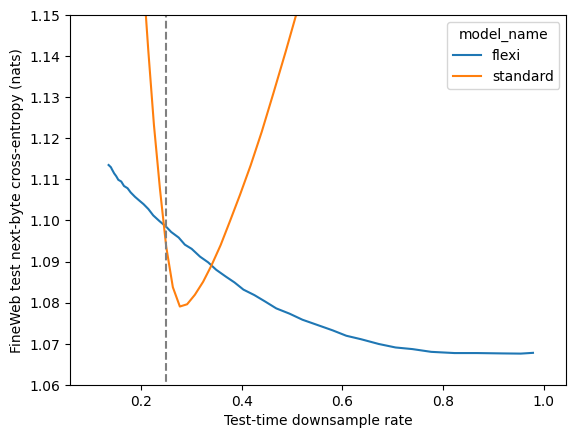

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=df_reduced, 
    x='true_downsample_rate',
    y='mean_next_token_cross_entropy',
    hue='model_name'
)

plt.xlabel("Test-time downsample rate")
plt.ylabel("FineWeb test next-byte cross-entropy (nats)")

plt.ylim(1.06, 1.15)
plt.vlines(0.25, 1.05, 1.2, color='gray', linestyle='--')